# Mixing matrix: Monte-Carlo error bars from multiple realisations

Loads every `test_*.h5` output in `blind_d0_DB_test_plot/Dict/` (one independent noise realisation per file) and:

1. Plots the fitted mixing matrix with **empirical (realisation-to-realisation) 1-sigma error bars**, alongside the Fisher/Hessian sigma reported by each individual fit (`A_err`), for comparison.
2. Plots the **evolution of each fitted mixing-matrix element across realisations** (reusing `PlotsCMM.plot_mixing_matrix_iteration`, treating the realisation index as the "iteration" axis).

Only `A`, `A_err`, `Atrue`, `nus_in`, `nus_out`, `comps_name`, `parameters` are loaded from each file (`HDF5Dict.load_dict(..., keys=...)`) — the map/TOD arrays are skipped since they dominate file size and aren't needed here.

In [1]:
import glob
import os
from types import SimpleNamespace

import numpy as np
from IPython.display import SVG, display

from qubic.lib.Qhdf5 import HDF5Dict
from qubic.lib.MapMaking.Qmap_plotter import PlotsCMM

In [2]:
foldername = "blind_d0_DB_test_plot"
files = sorted(glob.glob(f"{foldername}/Dict/test_*.h5"))
print(f"Found {len(files)} realisations")

hdf5 = HDF5Dict()
keys = ["A", "A_err", "Atrue", "nus_in", "nus_out", "comps_name", "parameters"]
realisations = [hdf5.load_dict(f, keys=keys) for f in files]

Found 58 realisations


In [3]:
nsub_in = realisations[0]["parameters"]["QUBIC"]["nsub_in"]
nsub_out = realisations[0]["parameters"]["QUBIC"]["nsub_out"]
n_bins = realisations[0]["parameters"]["Foregrounds"]["bin_mixing_matrix"]
fsub_out = nsub_out // n_bins
comp_names = [c.decode() if isinstance(c, bytes) else c for c in realisations[0]["comps_name"]]

nus_in = realisations[0]["nus_in"][:nsub_in]
Atrue_in = realisations[0]["Atrue"][:nsub_in, 1:]

# The true sky/instrument model is realisation-independent: sanity-check it actually is,
# in case some of these runs used a different config than the others.
for r in realisations[1:]:
    assert r["parameters"]["QUBIC"]["nsub_out"] == nsub_out
    assert r["parameters"]["Foregrounds"]["bin_mixing_matrix"] == n_bins
    assert np.allclose(r["nus_in"][:nsub_in], nus_in)
    assert np.allclose(r["Atrue"][:nsub_in, 1:], Atrue_in)

print(f"nsub_in={nsub_in}  nsub_out={nsub_out}  bin_mixing_matrix={n_bins}  comps={comp_names}")

nsub_in=12  nsub_out=12  bin_mixing_matrix=6  comps=['CMB', 'Dust']


In [4]:
def _bin_by_freq(arr, n_bins, fsub_out):
    """Average `arr` over each block of `fsub_out` consecutive output frequencies.

    Same binning as BlindMM._bin_by_freq: the blind fit only has `n_bins` independent
    values, each shared across `fsub_out` frequencies.
    """
    return np.array([arr[i * fsub_out : (i + 1) * fsub_out].mean(axis=0) for i in range(n_bins)])


nus_binned = _bin_by_freq(realisations[0]["nus_out"][:nsub_out], n_bins, fsub_out)

# shape (n_realisations, n_bins, ncomp - 1)
A_stack = np.array([_bin_by_freq(r["A"][:nsub_out, 1:], n_bins, fsub_out) for r in realisations])
fisher_sigma_stack = np.array(
    [_bin_by_freq(r["A_err"][:nsub_out, 1:], n_bins, fsub_out) for r in realisations]
)

mean_A = A_stack.mean(axis=0)
std_A = A_stack.std(axis=0, ddof=1)  # empirical ("Monte-Carlo") 1-sigma
mean_fisher_sigma = fisher_sigma_stack.mean(axis=0)

In [5]:
print(f"{'comp':10s} {'freq [GHz]':>10s} {'MC sigma':>12s} {'Fisher sigma':>14s} {'MC/Fisher':>10s}")
for ic, name in enumerate(comp_names[1:]):
    for ib in range(n_bins):
        ratio = std_A[ib, ic] / mean_fisher_sigma[ib, ic] if mean_fisher_sigma[ib, ic] > 0 else np.nan
        print(
            f"{name:10s} {nus_binned[ib]:10.1f} {std_A[ib, ic]:12.3e} "
            f"{mean_fisher_sigma[ib, ic]:14.3e} {ratio:10.2f}"
        )

comp       freq [GHz]     MC sigma   Fisher sigma  MC/Fisher
Dust            136.9    2.572e-05      2.561e-05       1.00
Dust            148.9    3.868e-05      3.421e-05       1.13
Dust            161.9    2.742e-05      2.285e-05       1.20
Dust            200.8    2.093e-05      1.954e-05       1.07
Dust            218.4    3.333e-05      3.100e-05       1.08
Dust            237.5    2.461e-05      2.111e-05       1.17


In [6]:
preset_stub = SimpleNamespace(
    job_id=0,
    tools=SimpleNamespace(
        params={
            "Plots": {"maps": True, "conv_beta": True},
            "foldername": foldername,
            "Foregrounds": realisations[0]["parameters"]["Foregrounds"],
        },
        rank=0,
    ),
    sky=SimpleNamespace(center=None, seenpix=None),
    comp=SimpleNamespace(components_name_out=comp_names, components_out=comp_names),
    acquisition=SimpleNamespace(rms_plot=np.zeros((0, 2))),
)
plots_cmm = PlotsCMM(preset_stub)

## Mixing matrix with Monte-Carlo error bars

Points/errors are the mean and std of the fitted value across all realisations (`A_out_err=std_A`), reusing the production `plot_sed`.

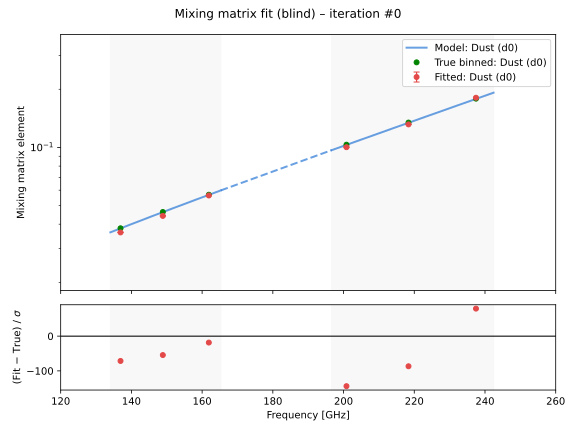

In [7]:
cwd = os.getcwd()
os.chdir("..")  # PlotsCMM methods save to "CMM/<foldername>/Plots/..."
try:
    plots_cmm.plot_sed(
        nus_in=nus_in,
        A_in=Atrue_in,
        nus_out=nus_binned,
        A_out=mean_A,
        A_out_err=std_A,
        ki=-1,
    )
finally:
    os.chdir(cwd)

display(SVG(filename=f"{foldername}/Plots/A_iter/A_iter0.svg"))

### Why the error bars in the plot above are barely visible

They *are* being drawn (`A_out_err=std_A`) — they're just tiny relative to the value range. For this run the realisation-to-realisation scatter is only ~0.02-0.09% of the fitted value (e.g. std ≈ 2.6e-5 on a mean of 0.036), invisible against a log-scale axis spanning two orders of magnitude (QUBIC + Planck bands together). The cell below shows that same scatter directly by superposing every individual realisation's fit instead of collapsing it to an error bar.

In [ ]:
import matplotlib.pyplot as plt

n_comp = len(comp_names) - 1
fig, axes = plt.subplots(1, n_comp, figsize=(7 * n_comp, 5), squeeze=False)
axes = axes[0]

for ic, name in enumerate(comp_names[1:]):
    ax = axes[ic]
    ax.plot(nus_in, Atrue_in[:, ic], color="black", ls="--", lw=2, alpha=0.8, zorder=3, label="True SED")
    for A_real in A_stack:
        ax.plot(nus_binned, A_real[:, ic], color="tab:blue", alpha=0.15, lw=1, marker="o", markersize=3)
    ax.plot(
        [], [], color="tab:blue", alpha=0.6, lw=1, marker="o", markersize=3,
        label=f"Individual realisations (n={len(realisations)})",
    )
    ax.plot(nus_binned, mean_A[:, ic], color="tab:red", lw=2.5, marker="o", markersize=6, zorder=4, label="Mean across realisations")
    ax.set_yscale("log")
    ax.set_xlabel("Frequency [GHz]")
    ax.set_ylabel("Mixing matrix element")
    ax.set_title(name)
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle(f"Fitted mixing matrix superposed across {len(realisations)} realisations")
fig.tight_layout()
plt.show()

## Evolution of the fitted value across realisations

Reuses `PlotsCMM.plot_mixing_matrix_iteration` (built for the PCG outer-loop history), here fed the per-realisation fitted values instead: the "iteration" axis is the realisation index (one point per independent noise draw), and the bottom panel shows `|A - A_true|` per realisation.

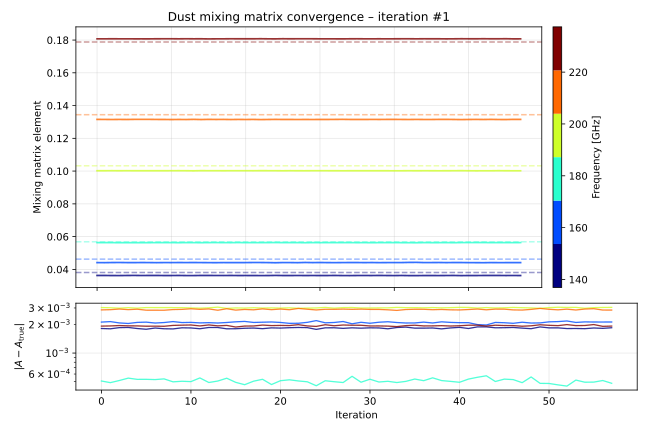

In [8]:
cwd = os.getcwd()
os.chdir("..")
try:
    for ic, name in enumerate(comp_names[1:]):
        truth_binned = _bin_by_freq(realisations[0]["Atrue"][:nsub_out, ic + 1], n_bins, fsub_out)
        plots_cmm.plot_mixing_matrix_iteration(
            A_stack[:, :, ic],
            truth=truth_binned,
            nus=nus_binned,
            name=name,
            ki=0,
        )
finally:
    os.chdir(cwd)

for name in comp_names[1:]:
    display(SVG(filename=f"{foldername}/Plots/A_iter/Amm_conv_{name}_iter1.svg"))